In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')
print('Data loaded successfully')
print(f'Training Set: {X_train.shape}')
print(f'Testing Set: {X_test.shape}')

Data loaded successfully
Training Set: (240, 7)
Testing Set: (60, 7)


In [5]:

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Fail', 'Pass']))

=== Logistic Regression ===
Accuracy: 70.00%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        18
        Pass       0.70      1.00      0.82        42

    accuracy                           0.70        60
   macro avg       0.35      0.50      0.41        60
weighted avg       0.49      0.70      0.58        60



C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [6]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Fail', 'Pass']))

=== Random Forest ===
Accuracy: 68.33%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        18
        Pass       0.69      0.98      0.81        42

    accuracy                           0.68        60
   macro avg       0.35      0.49      0.41        60
weighted avg       0.49      0.68      0.57        60



In [7]:

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print('Decision Tree')
print(f'Accuracy: {accuracy_score(y_test, dt_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred, target_names=['Fail', 'Pass']))

Decision Tree
Accuracy: 60.00%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.31      0.28      0.29        18
        Pass       0.70      0.74      0.72        42

    accuracy                           0.60        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.59      0.60      0.59        60



In [8]:

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred)*100,
        accuracy_score(y_test, rf_pred)*100,
        accuracy_score(y_test, dt_pred)*100
    ]
})

results = results.sort_values('Accuracy', ascending=False)
print('Model Comparison')
print(results.to_string(index=False))
print(f'\nBest Model: {results.iloc[0]["Model"]}')
print(f'Best Accuracy: {results.iloc[0]["Accuracy"]:.2f}%')

Model Comparison
              Model  Accuracy
Logistic Regression 70.000000
      Random Forest 68.333333
      Decision Tree 60.000000

Best Model: Logistic Regression
Best Accuracy: 70.00%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10124\4207642452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


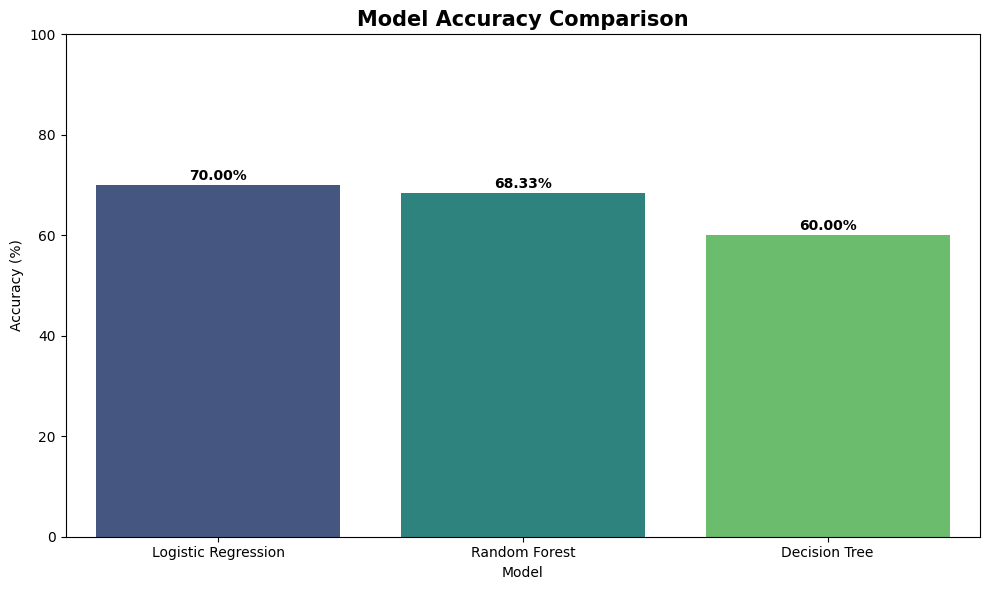

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Model', 
    y='Accuracy', 
    data=results, 
    palette='viridis'
)
plt.title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, row in results.iterrows():
    plt.text(
        i, row['Accuracy'] + 1,
        f'{row["Accuracy"]:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()